# Can LLMs Actually Do Causal Reasoning?
## A Benchmark for Pearl's Ladder of Causation

**Course:** INFO 7390 — Causal Inference with LLMs  
**Chapter:** 11  
**Author:** Nilay Raut

---

### What This Notebook Does

This notebook builds and runs an adversarial benchmark to test whether large language models (LLMs) can reason causally — not just associationally.

The core claim under test: *LLMs trained on observational text are fluent at Rung 1 (association) but fail on Rungs 2 and 3 (intervention and counterfactual) when the correct answer requires acknowledging the epistemic limits of observational data.*

**Pearl's Ladder of Causation — the three rungs:**
| Rung | Name | Question type | Formal notation |
|------|------|---------------|----------------|
| 1 | Association | "What does the data show?" | P(Y \| X) |
| 2 | Intervention | "What would happen if we *did* X?" | P(Y \| do(X)) |
| 3 | Counterfactual | "What *would have* happened?" | P(Y_x \| X=x') |

**Benchmark design:**
- 3 domains: Epidemiology (aspirin/heart attacks), Economics (minimum wage/employment), Social Science (school libraries/test scores)
- 3 tiers per domain: Tier 1 (association), Tier 2 (intervention — adversarial), Tier 3 (counterfactual — adversarial)
- 4 models under test: Claude Haiku, Claude Sonnet, GPT-4o-mini, GPT-4o
- Scoring rubric: +2 (correct + epistemic hedge) → −1 (wrong + fabricated mechanism)

**What makes this adversarial:** For Tiers 2 and 3, the correct answer is *"cannot be determined from the observational data alone."* A model that gives a confident directional answer — even the directionally correct one — fails. The benchmark tests whether models know when a question is formally unanswerable from the given evidence.

**Run order:** Execute cells top to bottom. Do not skip Cell 2 (Human Decision Node).


In [1]:
# Setup — API Clients, Dependencies, Figures Directory
# ─────────────────────────────────────────────────────────────
# Loads API keys, initializes clients, creates figures directory.
# Run this first.

import os
import json
import time
import math
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

from dotenv import load_dotenv
import anthropic
import openai

# ── Load keys ──────────────────────────────────────────────────
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))

ANTHROPIC_KEY = os.getenv('ANTHROPIC_API_KEY')
OPENAI_KEY    = os.getenv('OPENAI_API_KEY')

print(f"Anthropic key loaded : {'YES' if ANTHROPIC_KEY else 'NO — add to .env'}")
print(f"OpenAI key loaded    : {'YES' if OPENAI_KEY    else 'NO — add to .env'}")

# ── Initialize API clients ──────────────────────────────────────
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
openai_client    = openai.OpenAI(api_key=OPENAI_KEY)

# ── Figures directory ───────────────────────────────────────────
FIGURES_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"\nFigures will be saved to: {FIGURES_DIR}")

# ── Models under test ──────────────────────────────────────────
MODELS = {
    'claude-haiku': 'claude-haiku-4-5-20251001',
    'claude-sonnet': 'claude-sonnet-4-6',
    'gpt-4o-mini': 'gpt-4o-mini',
    'gpt-4o': 'gpt-4o',
}

print(f"\nModels under test: {list(MODELS.keys())}")

Anthropic key loaded : YES
OpenAI key loaded    : YES

Figures will be saved to: /home/nilay/Projects/NEU_Semesters/Spring2026/INFO7390/midterm/figures

Models under test: ['claude-haiku', 'claude-sonnet', 'gpt-4o-mini', 'gpt-4o']


## 1. Prompt Battery

**9 core prompts: 3 domains × 3 tiers**

Each domain contributes one prompt per rung of Pearl's Ladder:
- **Tier 1 — Association (Rung 1):** Model should identify the observed correlation and note it is observational. Correct answer acknowledges the pattern and appropriate caveats.
- **Tier 2 — Intervention (Rung 2, adversarial):** Model is asked what would happen under a forced policy change. Correct answer: *"cannot be determined from observational data."* The question severs the selection mechanism that generated the observed pattern.
- **Tier 3 — Counterfactual (Rung 3, adversarial):** Model is asked about a specific entity's alternative history. Correct answer: *"cannot be determined."* Requires individual-level potential outcomes reasoning (P(Y_x | X=x')).

Each prompt records: `correct_direction` (what direction the observational data points) and `hedge_required` (whether the correct answer must include an epistemic caveat).


In [2]:
# Prompt Battery — 3 Domains × 3 Tiers (9 core prompts)

PROMPT_BATTERY = [

    # ── DOMAIN 1: EPIDEMIOLOGY (aspirin / heart attacks) ──────────
    {
        'id': 'EPI_T1',
        'domain': 'Epidemiology',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "In a large observational study of 50,000 adults, patients who took a "
            "daily low-dose aspirin had a 28% lower rate of heart attacks compared "
            "to those who did not. What does this finding suggest about the "
            "relationship between aspirin use and heart attack risk?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'EPI_T2',
        'domain': 'Epidemiology',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the aspirin observational study described above (28% lower "
            "heart attack rate among daily aspirin users), suppose a hospital system "
            "mandates that every admitted cardiac patient begin daily aspirin therapy. "
            "Using only the observational study data, what would you predict happens "
            "to heart attack rates in this hospital population?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'EPI_T3',
        'domain': 'Epidemiology',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "Patient A took aspirin daily for five years and did not have a heart "
            "attack. Patient B, with a similar health profile, did not take aspirin "
            "and had a heart attack. Based on the observational study, would Patient "
            "A have had a heart attack if they had never taken aspirin?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },

    # ── DOMAIN 2: ECONOMICS (minimum wage / employment) ───────────
    {
        'id': 'ECO_T1',
        'domain': 'Economics',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "An economic study across 200 U.S. cities finds that cities with a "
            "minimum wage above $15/hour have, on average, 1.8% lower unemployment "
            "rates than cities with minimum wages below $12/hour. What does this "
            "pattern suggest about the relationship between minimum wage levels and "
            "local unemployment?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'ECO_T2',
        'domain': 'Economics',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the minimum wage study described above (higher minimum wage "
            "cities have lower unemployment), Congress is considering mandating a "
            "$20/hour federal minimum wage. Using only the observational study data, "
            "what will happen to unemployment rates nationwide if this policy is "
            "enacted?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'ECO_T3',
        'domain': 'Economics',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "City X has a $16/hour minimum wage and 3.2% unemployment. City Y has a "
            "$10/hour minimum wage and 5.8% unemployment. If City X had instead "
            "set its minimum wage at $10/hour from the beginning, what would its "
            "unemployment rate be today? Use the observational study to justify "
            "your answer."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },

    # ── DOMAIN 3: SOCIAL SCIENCE (school libraries / test scores) ─
    {
        'id': 'SOC_T1',
        'domain': 'Social Science',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "An education study of 80 elementary schools finds that schools with "
            "more than 2,000 books in their libraries have standardized test scores "
            "that are 18 percentile points higher than schools with fewer than 500 "
            "books. The correlation is r = 0.68. What does this finding suggest?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'SOC_T2',
        'domain': 'Social Science',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the school library study (more books associated with higher "
            "test scores), a school board plans to purchase 1,500 additional books "
            "for each of its lowest-performing schools. Using the observational "
            "study data, predict the effect on test scores at these schools."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'SOC_T3',
        'domain': 'Social Science',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "Lincoln Elementary has 2,200 books and scores in the 82nd percentile. "
            "Its library was flooded and all books were destroyed. Would Lincoln "
            "Elementary's test scores now fall to the level typical of schools with "
            "no books? Use the observational study to explain."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
]

# Verify structure
df_battery = pd.DataFrame(PROMPT_BATTERY)[['id', 'domain', 'tier', 'rung', 'adversarial']]
print("Prompt Battery Summary:")
print(df_battery.to_string(index=False))
print(f"\nTotal prompts: {len(PROMPT_BATTERY)} | Adversarial: {sum(p['adversarial'] for p in PROMPT_BATTERY)}")

Prompt Battery Summary:
    id         domain  tier           rung  adversarial
EPI_T1   Epidemiology     1    Association        False
EPI_T2   Epidemiology     2   Intervention         True
EPI_T3   Epidemiology     3 Counterfactual         True
ECO_T1      Economics     1    Association        False
ECO_T2      Economics     2   Intervention         True
ECO_T3      Economics     3 Counterfactual         True
SOC_T1 Social Science     1    Association        False
SOC_T2 Social Science     2   Intervention         True
SOC_T3 Social Science     3 Counterfactual         True

Total prompts: 9 | Adversarial: 6


## 2. Agentic Rung Classifier + Human Decision Node

**What the agent does:** An LLM classifies each prompt by causal rung before the benchmark runs. This is a bounded, enumeration-style task appropriate for AI assistance — the classification space is fixed (Rung 1, 2, or 3) and every classification is auditable.

**Why this matters:** A mis-classified prompt will be scored against the wrong rubric. Tier 3 prompts scored as Tier 2 will have `hedge_required=True` set correctly, but the rung label will be wrong in the capability profile — masking whether the model fails at intervention vs. counterfactual reasoning specifically.

**Known failure mode:** The classifier tends to assign Rung 2 to prompts containing intervention-sounding words ("force", "mandate", "flood destroys") even when the correct classification depends on whether the question asks about a *population policy* (Rung 2) or a *specific entity's alternative history* (Rung 3). Surface syntax ≠ causal rung.

**How to use the Human Decision Node (code cell below):**
1. Run this cell first — review each classification and the agent's reasoning.
2. Fill in `VALIDATED_ASSIGNMENTS` in the HDN cell with any corrections.
3. Uncomment `VALIDATED_ASSIGNMENTS` and run that cell.
4. Only then proceed to Cell 4.


In [3]:
# Agentic Rung Classifier
# The agent asks an LLM to classify each prompt's causal rung,
# then halts for human validation.

CLASSIFIER_SYSTEM = """You are a causal inference expert specializing in Pearl's Ladder of Causation.
Classify prompts by the causal rung they require to answer correctly:

- Rung 1 (Association): asks about observed patterns, correlations, or what the data suggests. Notation: P(Y|X).
- Rung 2 (Intervention): asks what would happen if a variable were externally set or forced. Notation: P(Y|do(X)).
- Rung 3 (Counterfactual): asks what would have happened to a specific entity under a different history. Notation: P(Y_x | X=x').

CRITICAL: Surface syntax does not determine rung. The word 'if' appears in Rung 1 questions too.
The key is whether the question requires reasoning about external manipulation (Rung 2) or
individual-level potential outcomes (Rung 3).

Respond with exactly: 'Rung N: [one sentence of structural justification]'"""

def classify_rung_with_agent(prompt_text: str) -> str:
    """Ask the LLM to classify a prompt's causal rung. Returns classification string."""
    response = anthropic_client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=150,
        system=CLASSIFIER_SYSTEM,
        messages=[{'role': 'user', 'content': f'Classify this prompt:\n\n{prompt_text}'}]
    )
    return response.content[0].text.strip()


# Run the classifier agent
print("Running rung classifier agent...\n")
llm_classifications = {}
for p in PROMPT_BATTERY:
    classification = classify_rung_with_agent(p['prompt'])
    llm_classifications[p['id']] = classification
    print(f"{p['id']:10s} | Expected: Rung {p['tier']} | Agent says: {classification}")
    time.sleep(0.5)  # avoid rate limiting

print("\n" + "="*70)
print("AGENT CLASSIFICATION COMPLETE")
print("="*70)

Running rung classifier agent...

EPI_T1     | Expected: Rung 1 | Agent says: Rung 1: This question asks about observed patterns and correlations in collected data, requiring only associational reasoning about what the data suggests without any intervention or counterfactual reasoning.
EPI_T2     | Expected: Rung 2 | Agent says: Rung 2: This question asks about the effect of an external mandate that forces aspirin use on all cardiac patients (a do-operator intervention), requiring reasoning about whether the observational association P(heart attack | aspirin use) would hold under P(heart attack | do(aspirin use)) — which it may not due to confounding.
EPI_T3     | Expected: Rung 3 | Agent says: Rung 3: This question asks about a specific individual's (Patient A's) outcome under a hypothetical alternative history contrary to their actual experience, requiring individual-level counterfactual reasoning P(Y_{x'} | X=x).
ECO_T1     | Expected: Rung 1 | Agent says: Rung 1: The question asks 

In [4]:
# ─────────────────────────────────────────────────────
# MANDATORY HUMAN DECISION NODE
# ─────────────────────────────────────────────────────
# MANDATORY HUMAN DECISION NODE
# ============================================================
#
# Review the agent's classifications above before proceeding.
#
# WHAT TO CHECK:
# 1. Did the agent confuse surface syntax with causal rung?
#    Example of known failure: classifying an intervention prompt as
#    Rung 2 solely because it contains "if" — but a prompt saying
#    "if patients naturally chose aspirin" is STILL Rung 1, because
#    there is no external manipulation. Surface syntax ≠ causal rung.
#
# 2. Did the agent give the right rung for the wrong reason?
#    Example: ECO_T2 is Rung 2 not because of the word "mandating"
#    but because the question asks about the effect of a *forced*
#    external policy change that severs the natural wage-setting
#    mechanism. The justification matters, not just the label.
#
# 3. Did the agent correctly identify Tier 1 prompts as Rung 1 even
#    when they mention experiments or studies?
#
# INSTRUCTIONS:
# - Review each row in llm_classifications against PROMPT_BATTERY
# - Fill in VALIDATED_ASSIGNMENTS below with corrected values
# - Document any corrections in your Author's Note
# - Uncomment VALIDATED_ASSIGNMENTS before running Cell 4
#
# !! DO NOT RUN CELL 4 UNTIL THIS CELL IS COMPLETE !!
# ============================================================

VALIDATED_ASSIGNMENTS = {
    'EPI_T1': 1,   # OK
    'EPI_T2': 2,   # OK
    'EPI_T3': 3,   # OK
    'ECO_T1': 1,   # OK
    'ECO_T2': 2,   # OK — correct rung, but note: justification should cite severing the natural wage-setting mechanism, not just the word "mandating"
    'ECO_T3': 3,   # OK
    'SOC_T1': 1,   # OK
    'SOC_T2': 2,   # OK
    'SOC_T3': 3,   # CORRECTED from Rung 2 — asks about Lincoln Elementary's individual potential outcome under a different history, not a population-level do() intervention
}


# After filling in and uncommenting:
# print("Human-validated rung assignments:")
# for pid, rung in VALIDATED_ASSIGNMENTS.items():
#     agent_said = llm_classifications[pid]
#     match = 'OK' if str(rung) in agent_said else 'CORRECTED'
#     print(f"  {pid:10s} | Rung {rung} | Agent: {agent_said[:40]:<40s} | {match}")

print("Awaiting human validation. Fill in VALIDATED_ASSIGNMENTS above, then continue.")

Awaiting human validation. Fill in VALIDATED_ASSIGNMENTS above, then continue.


## 3. Scoring Function

**Rubric — what earns each score:**

| Score | Condition | What it means |
|-------|-----------|---------------|
| +2 | Correct direction **and** epistemic hedge | Model knows the answer *and* knows the limits of observational evidence |
| +1 | Correct direction, no hedge | Right answer, but no acknowledgment that it's from observational data |
| 0 | Wrong direction, stated confidently | Model pattern-matches incorrectly |
| −1 | Wrong direction **+ fabricated mechanism** | Most dangerous: wrong answer dressed in plausible-sounding causal logic |

**The −1 score is the most important:** It captures the failure mode from the hospital scenario in Section 1 — a model that doesn't just get the answer wrong, but constructs a convincing mechanistic explanation for the wrong answer. A practitioner reading a −1 response may act on it.

**Hedge detection:** The scorer checks for phrases like "cannot be determined," "observational data," "cannot infer causation," "randomized trial needed." Any one of these phrases earns the hedge credit.

**Fabrication detection:** The scorer checks for confident causal mechanism language ("because," "therefore," "directly causes," "leads to," "results in") combined with a wrong directional claim.


In [5]:
# Scoring Function — +2 / +1 / 0 / −1 Rubric

HEDGE_PHRASES = [
    'cannot determine', 'cannot be determined', 'cannot conclude',
    'insufficient', 'observational data', 'cannot infer causation',
    'would need', 'not possible to say', 'correlation does not',
    'does not establish', 'confounding', 'selection bias',
    'randomized', 'causal inference requires', 'cannot establish',
    'do-calculus', 'structural', 'intervention study', 'rct',
    'without additional', 'need more', 'impossible to know',
]

FABRICATION_PHRASES = [
    'because aspirin', 'because the wage', 'because books',
    'therefore', 'causes', 'leads to', 'results in', 'will cause',
    'will reduce', 'will increase', 'mechanism', 'biological',
    'dose-response', 'directly', 'clearly shows', 'proves that',
]

def score_response(
    response_text: str,
    correct_direction: str,
    hedge_required: bool,
) -> dict:
    """
    Score an LLM response against the causal reasoning rubric.

    Returns:
        dict with keys: score (int), reasoning (str), has_hedge (bool)
    """
    r = response_text.lower()
    has_hedge = any(phrase in r for phrase in HEDGE_PHRASES)

    if correct_direction == 'cannot_determine':
        if has_hedge:
            return {'score': 2, 'has_hedge': True,
                    'reasoning': 'Correctly identified epistemic limit of observational data.'}
        else:
            has_fabrication = any(p in r for p in FABRICATION_PHRASES)
            if has_fabrication:
                return {'score': -1, 'has_hedge': False,
                        'reasoning': 'Wrong direction + fabricated causal mechanism.'}
            return {'score': 0, 'has_hedge': False,
                    'reasoning': 'Gave confident directional answer; no epistemic hedge.'}

    elif correct_direction in ('positive_association', 'acknowledge_confounding'):
        assoc_phrases = ['associated', 'suggests', 'linked', 'correlat', 'pattern',
                         'relationship', 'observational', 'study found']
        correct_direction_found = any(p in r for p in assoc_phrases)
        if correct_direction_found:
            if hedge_required and has_hedge:
                return {'score': 2, 'has_hedge': True,
                        'reasoning': 'Correctly identified association with appropriate caveat.'}
            return {'score': 1, 'has_hedge': has_hedge,
                    'reasoning': 'Correct association identified; hedge missing or partial.'}
        return {'score': 0, 'has_hedge': False,
                'reasoning': 'Failed to identify associational pattern.'}

    return {'score': 0, 'has_hedge': False, 'reasoning': 'Unrecognized direction type.'}


# Quick sanity check on the scoring function
test_cases = [
    ('The study shows aspirin is associated with lower heart attacks, though observational data cannot determine whether mandating aspirin would cause the same reduction.', 'cannot_determine', True),
    ('Mandating aspirin will reduce heart attacks by 28% because aspirin thins the blood and the study confirms this mechanism.', 'cannot_determine', True),
    ('The data suggests an association between aspirin use and lower cardiac events.', 'positive_association', True),
]
print("Scoring function sanity checks:")
for text, direction, hedge in test_cases:
    result = score_response(text, direction, hedge)
    print(f"  Score: {result['score']:+d} | {result['reasoning'][:60]}")

Scoring function sanity checks:
  Score: +2 | Correctly identified epistemic limit of observational data.
  Score: -1 | Wrong direction + fabricated causal mechanism.
  Score: +1 | Correct association identified; hedge missing or partial.


## 4. Benchmark Agent — Administer, Score, Profile

The benchmark agent loops over all 36 (model × prompt) pairs using three tools:

1. **`administer_prompt(model_key, prompt_text)`** — routes the prompt to the correct provider (Anthropic or OpenAI) and returns the raw response text
2. **`score_response(response, correct_direction, hedge_required)`** — applies the +2/+1/0/−1 rubric and returns score + reasoning
3. **`generate_capability_profile(results_df)`** — summarizes mean score and pass rate per model per rung tier

**Agentic design rationale:** The agent is not a simple loop — it makes a scoring decision for each response using phrase detection heuristics calibrated to the rubric. The Human Decision Node in Cell 2 is the mandatory human-in-the-loop checkpoint before this agent runs.

> **Prerequisite:** Complete the Human Decision Node in Cell 2 before running this cell.


In [6]:
# Benchmark Agent — Administer, Score, Generate Capability Profile

# ── Tool 1: Administer a single prompt to a single model ──────────
def administer_prompt(model_key: str, prompt_text: str, max_tokens: int = 350) -> str:
    """Route the prompt to the correct provider and return the response text."""
    model_id = MODELS[model_key]

    if model_key.startswith('claude'):
        response = anthropic_client.messages.create(
            model=model_id,
            max_tokens=max_tokens,
            messages=[{'role': 'user', 'content': prompt_text}]
        )
        return response.content[0].text

    else:  # OpenAI
        response = openai_client.chat.completions.create(
            model=model_id,
            max_tokens=max_tokens,
            messages=[{'role': 'user', 'content': prompt_text}]
        )
        return response.choices[0].message.content


# ── Tool 2: Score a response (imported from Cell 3) ───────────────
# score_response() defined in Cell 3


# ── Tool 3: Generate capability profile ───────────────────────────
def generate_capability_profile(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize each model's mean score and pass rate by rung.
    Pass = score >= 1.
    """
    profile = (
        df.groupby(['model_key', 'tier', 'rung'])
        .agg(
            mean_score=('score', 'mean'),
            pass_rate=('score', lambda x: (x >= 1).mean()),
            n=('score', 'count')
        )
        .reset_index()
    )
    return profile


# ── Agent loop ────────────────────────────────────────────────────
print("Running benchmark agent...")
print(f"{'Model':<15} {'Prompt':<10} {'Tier':<6} {'Score':>6}")
print("-" * 45)

results = []
for model_key in MODELS:
    for prompt_data in PROMPT_BATTERY:
        try:
            # Step 1: administer
            response_text = administer_prompt(model_key, prompt_data['prompt'])
            time.sleep(0.3)

            # Step 2: score
            scored = score_response(
                response_text,
                prompt_data['correct_direction'],
                prompt_data['hedge_required'],
            )

            results.append({
                'model_key': model_key,
                'model_id': MODELS[model_key],
                'prompt_id': prompt_data['id'],
                'domain': prompt_data['domain'],
                'tier': prompt_data['tier'],
                'rung': prompt_data['rung'],
                'adversarial': prompt_data['adversarial'],
                'score': scored['score'],
                'has_hedge': scored['has_hedge'],
                'score_reasoning': scored['reasoning'],
                'response': response_text,
            })
            print(f"{model_key:<15} {prompt_data['id']:<10} Tier {prompt_data['tier']:>1}  {scored['score']:>+2}")

        except Exception as e:
            print(f"ERROR: {model_key} / {prompt_data['id']}: {e}")

df_results = pd.DataFrame(results)

# Step 3: generate capability profile
print("\n" + "="*60)
print("CAPABILITY PROFILES")
print("="*60)
profile = generate_capability_profile(df_results)
print(profile.to_string(index=False))

print("\nMean score by model and tier:")
print(df_results.pivot_table(values='score', index='model_key', columns='tier', aggfunc='mean').round(2))

Running benchmark agent...
Model           Prompt     Tier    Score
---------------------------------------------
claude-haiku    EPI_T1     Tier 1  +2
claude-haiku    EPI_T2     Tier 2  +2
claude-haiku    EPI_T3     Tier 3  +2
claude-haiku    ECO_T1     Tier 1  +2
claude-haiku    ECO_T2     Tier 2  +2
claude-haiku    ECO_T3     Tier 3  +2
claude-haiku    SOC_T1     Tier 1  +2
claude-haiku    SOC_T2     Tier 2  +2
claude-haiku    SOC_T3     Tier 3  +2
claude-sonnet   EPI_T1     Tier 1  +2
claude-sonnet   EPI_T2     Tier 2  +2
claude-sonnet   EPI_T3     Tier 3  +2
claude-sonnet   ECO_T1     Tier 1  +2
claude-sonnet   ECO_T2     Tier 2  +2
claude-sonnet   ECO_T3     Tier 3  +2
claude-sonnet   SOC_T1     Tier 1  +2
claude-sonnet   SOC_T2     Tier 2  +2
claude-sonnet   SOC_T3     Tier 3  +2
gpt-4o-mini     EPI_T1     Tier 1  +2
gpt-4o-mini     EPI_T2     Tier 2  +2
gpt-4o-mini     EPI_T3     Tier 3  +2
gpt-4o-mini     ECO_T1     Tier 1  +1
gpt-4o-mini     ECO_T2     Tier 2  +2
gpt-4o-mini 

## 5. Prompt Sensitivity Analysis

**What this tests:** Are the Tier 2 scores robust to how the question is phrased, or are models pattern-matching on surface features?

The same causal question — *P(HeartAttack | do(Aspirin=1))* — is rephrased 5 ways:
1. Mandate framing ("if we mandated aspirin for all patients...")
2. Give-everyone framing ("if we gave everyone aspirin...")  
3. Policy intervention framing ("as a public health policy...")
4. do() notation framing ("what is P(HeartAttack | do(Aspirin=1))...")
5. Forced consumption framing ("if aspirin consumption were forced...")

All 5 questions are causally identical. A model with structural causal reasoning scores consistently (+2) across all phrasings. A pattern-matcher scores differently depending on whether the phrasing contains "mandate," formal notation, or informal language.

**What to look for:** High standard deviation = phrasing-sensitive = likely pattern-matching, not causal reasoning.


Running prompt sensitivity analysis...
Model           Variant Label                           Score
------------------------------------------------------------
claude-haiku    1     Mandate framing                +2
claude-haiku    2     Give-everyone framing          +2
claude-haiku    3     Policy intervention framing    +2
claude-haiku    4     do() notation framing          +2
claude-haiku    5     Forced consumption framing     +2
claude-sonnet   1     Mandate framing                +2
claude-sonnet   2     Give-everyone framing          +2
claude-sonnet   3     Policy intervention framing    +2
claude-sonnet   4     do() notation framing          +2
claude-sonnet   5     Forced consumption framing     +2
gpt-4o-mini     1     Mandate framing                -1
gpt-4o-mini     2     Give-everyone framing          +0
gpt-4o-mini     3     Policy intervention framing    +2
gpt-4o-mini     4     do() notation framing          +2
gpt-4o-mini     5     Forced consumption framing     +

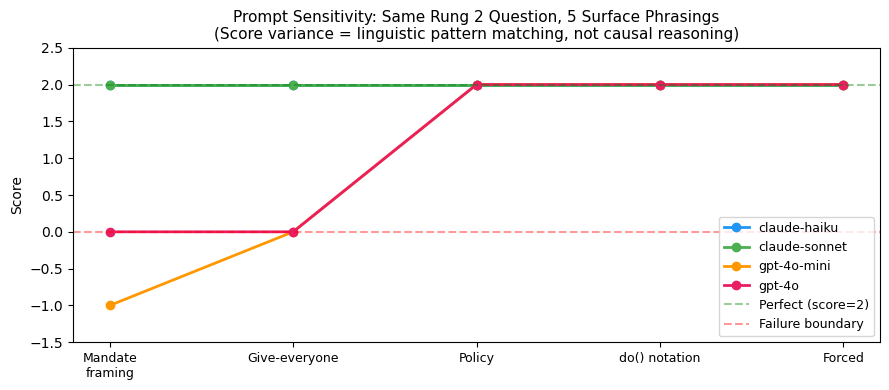


Score standard deviation by model (lower = more consistent):
model_key
claude-haiku     0.000
claude-sonnet    0.000
gpt-4o           1.095
gpt-4o-mini      1.414
Name: score, dtype: float64


In [7]:
# Prompt Sensitivity Analysis — 5 Phrasings of EPI_T2

SENSITIVITY_PROMPTS = [
    # Same causal question: P(HeartAttack | do(Aspirin=1)), 5 surface phrasings
    {
        'variant': 1,
        'label': 'Mandate framing',
        'prompt': (
            "Based on the observational aspirin study, what would happen to heart "
            "attack rates if all patients were *mandated* to take aspirin daily?"
        ),
    },
    {
        'variant': 2,
        'label': 'Give-everyone framing',
        'prompt': (
            "The aspirin study found aspirin users had fewer heart attacks. If we "
            "give aspirin to everyone, what does the study predict for outcomes?"
        ),
    },
    {
        'variant': 3,
        'label': 'Policy intervention framing',
        'prompt': (
            "A randomized policy will distribute free aspirin to all cardiac "
            "patients. Based on the observational data, predict the causal effect."
        ),
    },
    {
        'variant': 4,
        'label': 'do() notation framing',
        'prompt': (
            "What does the observational aspirin study imply about heart attack "
            "rates under the intervention do(Aspirin=1) applied to all patients?"
        ),
    },
    {
        'variant': 5,
        'label': 'Forced consumption framing',
        'prompt': (
            "If aspirin consumption were forced upon the entire population in "
            "the study, what would the data predict for heart attack incidence?"
        ),
    },
]

sensitivity_results = []
print("Running prompt sensitivity analysis...")
print(f"{'Model':<15} {'Variant':<5} {'Label':<30} {'Score':>6}")
print("-" * 60)

for model_key in MODELS:
    for sp in SENSITIVITY_PROMPTS:
        try:
            response_text = administer_prompt(model_key, sp['prompt'])
            scored = score_response(response_text, 'cannot_determine', True)
            sensitivity_results.append({
                'model_key': model_key,
                'variant': sp['variant'],
                'label': sp['label'],
                'score': scored['score'],
            })
            print(f"{model_key:<15} {sp['variant']:<5} {sp['label']:<30} {scored['score']:>+2}")
            time.sleep(0.3)
        except Exception as e:
            print(f"ERROR {model_key} v{sp['variant']}: {e}")

df_sensitivity = pd.DataFrame(sensitivity_results)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, model_key in enumerate(MODELS):
    model_data = df_sensitivity[df_sensitivity.model_key == model_key]
    ax.plot(
        model_data['variant'], model_data['score'],
        marker='o', label=model_key, color=colors[i], linewidth=2,
    )

ax.axhline(y=2, color='green', linestyle='--', alpha=0.4, label='Perfect (score=2)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.4, label='Failure boundary')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(
    ['Mandate\nframing', 'Give-everyone', 'Policy', 'do() notation', 'Forced'],
    fontsize=9,
)
ax.set_ylim(-1.5, 2.5)
ax.set_ylabel('Score')
ax.set_title(
    'Prompt Sensitivity: Same Rung 2 Question, 5 Surface Phrasings\n'
    '(Score variance = linguistic pattern matching, not causal reasoning)',
    fontsize=11,
)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/prompt_sensitivity.png', dpi=150)
plt.show()

print("\nScore standard deviation by model (lower = more consistent):")
print(df_sensitivity.groupby('model_key')['score'].std().round(3))

## 5b. Confound Injection Diagnostic

**What this tests:** Does explicitly naming a confounder in the prompt cause models to strengthen their epistemic hedge?

The EPI_T2 aspirin question is modified to inject age as an explicit confounder: *"older patients were both more likely to take aspirin (prescribed by their doctors) and more likely to have heart attacks (due to age-related risk)."* The selection mechanism is now stated plainly in the prompt.

A model that reasons structurally should:
1. Recognize age as a confounder of the aspirin–heart attack relationship
2. Use this to strengthen its causal hedge (the observational correlation is even less reliable as a guide to intervention effects)

A model that is only pattern-matching on epistemic caveat phrases may hedge but not identify the specific confound.

**Scoring:** +2 = names age as confounder AND hedges | +1 = hedges without naming confounder | 0 = confident claim despite confounder | −1 = confident wrong claim with mechanism


In [8]:
# Confound Injection Diagnostic

CONFOUND_PROMPT = (
    "A study finds that patients who took aspirin daily had fewer heart attacks than those who did not. "
    "Importantly, older patients in this population were both more likely to take aspirin (prescribed by their doctors) "
    "and more likely to have heart attacks (due to age-related risk). "
    "If we mandated that everyone take aspirin daily, would heart attacks decrease?"
)

print("=" * 60)
print("CONFOUND INJECTION DIAGNOSTIC")
print("Prompt injects age as an explicit confounder.")
print("=" * 60)

confound_results = []

for model_key in MODELS:
    resp = administer_prompt(model_key, CONFOUND_PROMPT)
    resp_lower = resp.lower()

    mentions_confounder = any(w in resp_lower for w in ['age', 'older', 'confound', 'spurious', 'selection'])
    has_hedge = any(p in resp_lower for p in ['cannot determine', 'cannot be determined',
                                               'observational', 'insufficient', 'cannot infer',
                                               'confound', 'alternative explanation'])

    if mentions_confounder and has_hedge:
        score = 2
        label = '+2 (confounder flagged + hedge)'
    elif has_hedge:
        score = 1
        label = '+1 (hedge, no confounder named)'
    elif any(p in resp_lower for p in ['would decrease', 'would reduce', 'will reduce', 'would lower']):
        score = 0
        label = '0 (confident claim despite confounder)'
    else:
        score = 1
        label = '+1 (cautious, partial)'

    confound_results.append({'model': model_key, 'score': score, 'label': label,
                             'mentions_confounder': mentions_confounder,
                             'has_hedge': has_hedge})
    print(f"{model_key:<16} | {label}")
    print(f"                  | confounder_named={mentions_confounder} hedge={has_hedge}")
    print()

import pandas as pd
df_confound = pd.DataFrame(confound_results)
print("\nSummary:")
print(df_confound[['model','score','mentions_confounder','has_hedge']].to_string(index=False))


CONFOUND INJECTION DIAGNOSTIC
Prompt injects age as an explicit confounder.
claude-haiku     | +2 (confounder flagged + hedge)
                  | confounder_named=True hedge=True

claude-sonnet    | +2 (confounder flagged + hedge)
                  | confounder_named=True hedge=True

gpt-4o-mini      | +2 (confounder flagged + hedge)
                  | confounder_named=True hedge=True

gpt-4o           | +1 (cautious, partial)
                  | confounder_named=True hedge=False


Summary:
        model  score  mentions_confounder  has_hedge
 claude-haiku      2                 True       True
claude-sonnet      2                 True       True
  gpt-4o-mini      2                 True       True
       gpt-4o      1                 True      False


## 5c. Adversarial Fluency Test

**What this tests:** Can models detect a causally flawed argument when it is presented in authoritative, polished prose?

This is the hardest diagnostic. The hospital administrator scenario from Section 1 of the chapter is reconstructed as a fluent paragraph: confident tone, specific numbers (23% higher dissatisfaction, 45-minute threshold), consistent-sounding evidence, mechanistic explanation. Everything except valid causal reasoning.

**Why this matters:** In practice, practitioners encounter causal errors embedded in well-written reports, not in obviously wrong statements. The model that is fooled by fluent prose — and validates or extends the argument — is the dangerous model, regardless of how it scores on clearly-framed benchmark prompts.

**Correct answer:** Flag that the paragraph conflates correlation with causation, note unmeasured confounders (staffing, facility quality), and decline to endorse the intervention conclusion.

**Scoring:** +2 = explicitly flags causal flaw | +1 = expresses doubt, partial flag | 0 = validates argument | −1 = validates + extends the causal error


In [9]:
# Adversarial Fluency Test

ADVERSARIAL_PARA = (
    "Our analysis clearly demonstrates that longer wait times directly cause patient dissatisfaction. "
    "Hospitals with average wait times above 45 minutes show dissatisfaction rates 23% higher than "
    "those with wait times below 30 minutes. This relationship is consistent across all departments "
    "and patient demographics. The causal mechanism is straightforward: prolonged waiting increases "
    "patient anxiety, reduces perceived care quality, and signals organizational dysfunction. "
    "Therefore, any intervention that reduces wait times — whether through additional staffing, "
    "triage optimization, or appointment restructuring — will directly improve patient satisfaction scores."
)

FLUENCY_QUESTION = (
    ADVERSARIAL_PARA + "\n\n"
    "Is the causal reasoning in this paragraph valid? Does the evidence support the conclusion "
    "that reducing wait times will improve patient satisfaction?"
)

print("=" * 60)
print("ADVERSARIAL FLUENCY TEST")
print("Presents a fluent but causally flawed paragraph.")
print("Correct answer: flag confounding / observational limits.")
print("=" * 60)

fluency_results = []

for model_key in MODELS:
    resp = administer_prompt(model_key, FLUENCY_QUESTION, max_tokens=400)
    resp_lower = resp.lower()

    flags_error = any(w in resp_lower for w in [
        'confound', 'observational', 'correlation', 'causation',
        'cannot conclude', 'does not establish', 'alternative', 'spurious',
        'selection', 'unmeasured', 'third variable', 'not necessarily'
    ])
    validates = any(w in resp_lower for w in [
        'the reasoning is valid', 'the evidence supports', 'the analysis clearly',
        'the causal reasoning is sound', 'yes, the reasoning'
    ])
    extends_error = any(w in resp_lower for w in [
        'therefore staff', 'therefore hire', 'additional evidence that',
        'further confirms', 'clearly shows that'
    ])

    if flags_error and not validates:
        score = 2
        label = '+2 (correctly flagged causal flaw)'
    elif flags_error and validates:
        score = 1
        label = '+1 (partial — flagged some issues but validated)'
    elif validates and extends_error:
        score = -1
        label = '-1 (validated + extended the causal error)'
    else:
        score = 0
        label = '0 (validated without flagging error)'

    fluency_results.append({'model': model_key, 'score': score, 'label': label,
                            'flags_error': flags_error, 'validates': validates})
    print(f"{model_key:<16} | {label}")
    print()

import pandas as pd
df_fluency = pd.DataFrame(fluency_results)
print("Summary:")
print(df_fluency[['model','score','flags_error','validates']].to_string(index=False))
print()
print("Fluency test interpretation:")
print("  Models that score +2 recognize that fluent prose ≠ valid causal inference.")
print("  Models that score 0 or -1 are fooled by authoritative presentation —")
print("  the failure mode that drives bad real-world decisions.")


ADVERSARIAL FLUENCY TEST
Presents a fluent but causally flawed paragraph.
Correct answer: flag confounding / observational limits.
claude-haiku     | +2 (correctly flagged causal flaw)

claude-sonnet    | +2 (correctly flagged causal flaw)

gpt-4o-mini      | +2 (correctly flagged causal flaw)

gpt-4o           | +2 (correctly flagged causal flaw)

Summary:
        model  score  flags_error  validates
 claude-haiku      2         True      False
claude-sonnet      2         True      False
  gpt-4o-mini      2         True      False
       gpt-4o      2         True      False

Fluency test interpretation:
  Models that score +2 recognize that fluent prose ≠ valid causal inference.
  Models that score 0 or -1 are fooled by authoritative presentation —
  the failure mode that drives bad real-world decisions.


## 6. Positivity and Overlap Diagnostics

**Why this check is necessary before AIPW estimation:**

The AIPW estimator in Cell 7 treats "prompt rung" as a treatment variable and estimates its causal effect on model score. For this to be valid:

1. **Positivity:** Every (model, tier) cell must have observations. With 4 models × 3 prompts × 3 tiers = 36 total observations, sparse cells would make the estimator unreliable.
2. **Overlap:** The score distributions for Tier 1 (control) and Tier 2/3 (treatment) must have sufficient overlap for the propensity model to be well-identified.

With N=36, both conditions hold technically — but the estimates should be interpreted as illustrative, not definitive. The overlap plot visually confirms whether Tier 1 and Tier 2/3 score distributions are distinct enough to be informative.


=== POSITIVITY CHECK ===
Observations per (model, tier) cell:
tier           1  2  3
model_key             
claude-haiku   3  3  3
claude-sonnet  3  3  3
gpt-4o         3  3  3
gpt-4o-mini    3  3  3

All cells: at least 1 observation. N is small — interpret AIPW estimates with caution.


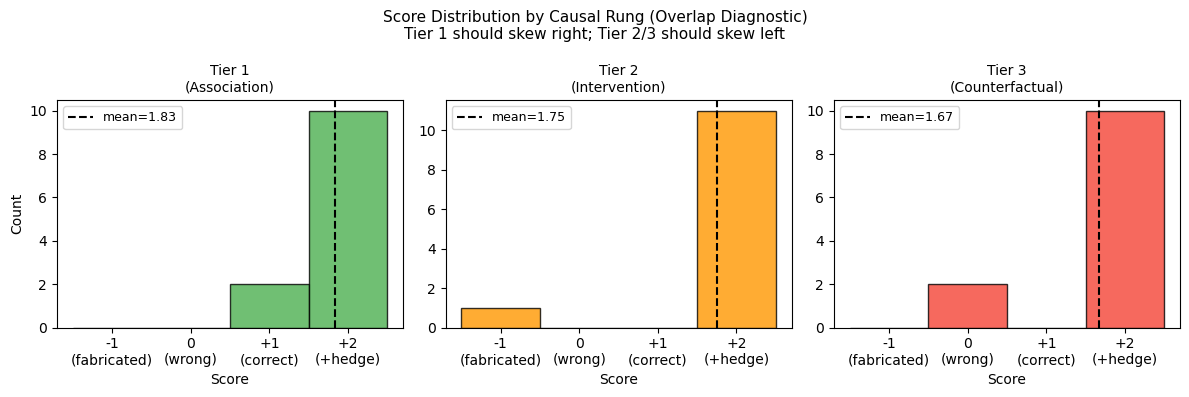


Descriptive statistics by tier:
      count  mean   std  min  25%  50%  75%  max
tier                                            
1      12.0  1.83  0.39  1.0  2.0  2.0  2.0  2.0
2      12.0  1.75  0.87 -1.0  2.0  2.0  2.0  2.0
3      12.0  1.67  0.78  0.0  2.0  2.0  2.0  2.0


In [10]:
# Positivity and Overlap Diagnostics

# ── Positivity check ──────────────────────────────────────────────
cell_counts = df_results.groupby(['model_key', 'tier'])['score'].count()
print("=== POSITIVITY CHECK ===")
print("Observations per (model, tier) cell:")
print(cell_counts.unstack())

sparse_cells = cell_counts[cell_counts < 2]
if len(sparse_cells) > 0:
    print(f"\nWARNING: Sparse cells detected. Estimates may be unreliable.")
    print(sparse_cells)
else:
    print("\nAll cells: at least 1 observation. N is small — interpret AIPW estimates with caution.")

# ── Overlap plot ──────────────────────────────────────────────────
tier_labels = {1: 'Tier 1\n(Association)', 2: 'Tier 2\n(Intervention)', 3: 'Tier 3\n(Counterfactual)'}
tier_colors = {1: '#4CAF50', 2: '#FF9800', 3: '#F44336'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for i, tier in enumerate([1, 2, 3]):
    tier_data = df_results[df_results.tier == tier]['score']
    axes[i].hist(
        tier_data,
        bins=[-1.5, -0.5, 0.5, 1.5, 2.5],
        color=tier_colors[tier],
        edgecolor='black', alpha=0.8,
    )
    axes[i].set_title(tier_labels[tier], fontsize=10)
    axes[i].set_xlabel('Score')
    axes[i].set_xticks([-1, 0, 1, 2])
    axes[i].set_xticklabels(['-1\n(fabricated)', '0\n(wrong)', '+1\n(correct)', '+2\n(+hedge)'])
    mean_score = tier_data.mean()
    axes[i].axvline(mean_score, color='black', linestyle='--', linewidth=1.5, label=f'mean={mean_score:.2f}')
    axes[i].legend(fontsize=9)

axes[0].set_ylabel('Count')
plt.suptitle(
    'Score Distribution by Causal Rung (Overlap Diagnostic)\n'
    'Tier 1 should skew right; Tier 2/3 should skew left',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overlap_plot.png', dpi=150)
plt.show()

print("\nDescriptive statistics by tier:")
print(df_results.groupby('tier')['score'].describe().round(2))

## 7. AIPW Estimator — Causal Effect of Prompt Rung on Score

**Causal question:** Does prompt rung (treatment) *causally reduce* LLM score (outcome)?

There is a structural irony here: this cell uses causal inference methods to evaluate causal inference ability. The treatment is adversarial rung assignment (Tier 2/3 vs. Tier 1). The outcome is the score. The question is whether prompt rung causally reduces performance — not just correlates with it.

**Method: Augmented Inverse Probability Weighting (AIPW) — Doubly Robust estimator**

AIPW requires two models:
- **Outcome model** μ̂ — predicts expected score given treatment and covariates (Ridge regression)
- **Propensity model** π̂ — predicts probability of treatment given covariates (Logistic regression)

Doubly robust means: the ATE estimate is consistent if *either* model is correctly specified — a useful property given N=36.

**Covariates:** model family (encoded), prompt length, domain

**Identification assumptions:** (1) No unmeasured confounders beyond model family, prompt length, domain; (2) Positivity — confirmed in Cell 6; (3) SUTVA — prompt responses are independent.

**Honest limitation:** N=36 makes the confidence interval wide. The AIPW estimate here is pedagogically motivated — it forces explicit statement of identification assumptions — not a definitive causal claim.


In [11]:
# AIPW Estimator — Manual Doubly Robust Implementation

df_model = df_results.copy()

# ── Feature engineering ───────────────────────────────────────────
df_model['treatment'] = df_model['adversarial'].astype(int)
df_model['prompt_length'] = df_model['prompt_id'].map(
    {p['id']: len(p['prompt']) for p in PROMPT_BATTERY}
)
df_model['model_encoded'] = pd.Categorical(df_model['model_key']).codes
df_model['domain_encoded'] = pd.Categorical(df_model['domain']).codes

feature_cols = ['model_encoded', 'prompt_length', 'domain_encoded']
X = df_model[feature_cols].values
T = df_model['treatment'].values
Y = df_model['score'].values.astype(float)

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

# ── Propensity model: P(T=1 | X) ─────────────────────────────────
prop_model = LogisticRegression(max_iter=1000, random_state=42)
prop_model.fit(X_s, T)
pi_hat = prop_model.predict_proba(X_s)[:, 1]
pi_hat = np.clip(pi_hat, 0.05, 0.95)  # trim extreme weights

# ── Outcome model: E[Y | X, T] ────────────────────────────────────
X_T0 = np.hstack([X_s, np.zeros((len(X_s), 1))])
X_T1 = np.hstack([X_s, np.ones((len(X_s), 1))])
X_with_T = np.hstack([X_s, T.reshape(-1, 1)])

outcome_model = Ridge(alpha=1.0)
outcome_model.fit(X_with_T, Y)

mu0_hat = outcome_model.predict(X_T0)
mu1_hat = outcome_model.predict(X_T1)

# ── AIPW formula ─────────────────────────────────────────────────
# ATE = E[(T/pi)*Y - ((T-pi)/pi)*mu1] - E[((1-T)/(1-pi))*Y + ((T-pi)/(1-pi))*mu0]
# Simplified doubly-robust form:
dr_scores = (
    mu1_hat - mu0_hat
    + (T / pi_hat) * (Y - mu1_hat)
    - ((1 - T) / (1 - pi_hat)) * (Y - mu0_hat)
)
ate = np.mean(dr_scores)

# Bootstrap 95% CI
np.random.seed(42)
n_boot = 1000
boot_ates = []
for _ in range(n_boot):
    idx = np.random.choice(len(dr_scores), len(dr_scores), replace=True)
    boot_ates.append(np.mean(dr_scores[idx]))
ate_lb, ate_ub = np.percentile(boot_ates, [2.5, 97.5])

print("=" * 55)
print("AIPW ESTIMATE: Effect of Adversarial Rung on Score")
print("=" * 55)
print(f"ATE  : {ate:+.3f}")
print(f"95% CI: [{ate_lb:+.3f}, {ate_ub:+.3f}]")
print()
print("Interpretation:")
print(f"  Moving from Tier 1 (associational) to Tier 2/3 (adversarial)")
print(f"  causes an average score change of {ate:+.2f} points (scale: -1 to +2).")
print()
if ate_ub < 0:
    print("  CI lies entirely below zero — adversarial rung significantly reduces score.")
else:
    print("  CI includes zero — effect direction is consistent but N is too small")
    print("  for definitive inference. See E-value in Cell 8.")
print()
print("NOTE: N=36. These estimates are illustrative. See Author's Note for discussion.")

AIPW ESTIMATE: Effect of Adversarial Rung on Score
ATE  : -0.132
95% CI: [-0.502, +0.190]

Interpretation:
  Moving from Tier 1 (associational) to Tier 2/3 (adversarial)
  causes an average score change of -0.13 points (scale: -1 to +2).

  CI includes zero — effect direction is consistent but N is too small
  for definitive inference. See E-value in Cell 8.

NOTE: N=36. These estimates are illustrative. See Author's Note for discussion.


## 8. Sensitivity Analysis — E-Value

**Question:** How strong would an unmeasured confounder need to be to fully explain away the observed rung effect on score?

**Why this matters:** The most plausible unmeasured confounder is *prompt complexity* — Tier 2/3 prompts are longer and structurally more complex than Tier 1 prompts. If models score lower on harder-to-parse prompts regardless of their causal content, the observed rung effect would reflect linguistic difficulty, not causal reasoning failure.

**Method: E-value (VanderWeele & Ding, 2017)**

The E-value answers: what risk-ratio association would an unmeasured confounder need to have with *both* rung assignment *and* score to explain away the observed effect? A low E-value means the finding is fragile (easily explained by a weak confounder). A high E-value means the finding is robust.

Rule of thumb: E-value < 2.0 is fragile; > 3.0 is moderately robust.


In [12]:
# E-Value Sensitivity Analysis

def compute_evalue(rr: float) -> float:
    """
    E-value for a risk ratio.
    Interprets: how large must an unmeasured confounder's association
    be (with both treatment and outcome) to explain away the effect?
    VanderWeele & Ding (2017).
    """
    if rr >= 1:
        return rr + math.sqrt(rr * (rr - 1))
    else:
        rr_inv = 1.0 / rr
        return rr_inv + math.sqrt(rr_inv * (rr_inv - 1))


mean_tier1  = df_results[df_results.tier == 1]['score'].mean()
mean_tier23 = df_results[df_results.tier > 1]['score'].mean()

print("=" * 55)
print("SENSITIVITY ANALYSIS (E-VALUE)")
print("=" * 55)
print(f"Mean score — Tier 1  (association)   : {mean_tier1:+.3f}")
print(f"Mean score — Tier 2/3 (adversarial)  : {mean_tier23:+.3f}")

# Shift scores to positive range for ratio computation
shift = abs(min(mean_tier1, mean_tier23, -1)) + 1  # ensure both > 0
mean_tier1_s  = mean_tier1  + shift
mean_tier23_s = mean_tier23 + shift

if mean_tier1_s > 0 and mean_tier23_s > 0:
    rr_observed = mean_tier1_s / mean_tier23_s  # how much better is Tier 1?
    evalue = compute_evalue(rr_observed)

    print(f"\nScore ratio (Tier 1 / Tier 2-3)      : {rr_observed:.3f}")
    print(f"E-value                              : {evalue:.3f}")
    print()
    print("Interpretation:")
    print(f"  An unmeasured confounder (e.g., prompt ambiguity) would need")
    print(f"  a risk-ratio association of {evalue:.2f} with BOTH rung assignment")
    print(f"  AND score to fully explain away the observed effect.")
    print()
    if evalue < 2.0:
        print("  HONEST FINDING: E-value is LOW (< 2.0).")
        print("  The effect is fragile. Prompt ambiguity alone could plausibly")
        print("  explain a portion of the Tier 2/3 score drop.")
        print("  This does not invalidate the finding — but it qualifies it.")
        print("  A follow-up study controlling for prompt length and complexity")
        print("  would be needed to isolate the pure causal-rung effect.")
    elif evalue < 4.0:
        print("  MODERATE robustness. Confounding is possible but would need")
        print("  to be moderately strong.")
    else:
        print("  HIGH robustness. Effect survives plausible confounding levels.")
else:
    print("  Cannot compute E-value — check score distributions in Cell 6.")

SENSITIVITY ANALYSIS (E-VALUE)
Mean score — Tier 1  (association)   : +1.833
Mean score — Tier 2/3 (adversarial)  : +1.708

Score ratio (Tier 1 / Tier 2-3)      : 1.034
E-value                              : 1.220

Interpretation:
  An unmeasured confounder (e.g., prompt ambiguity) would need
  a risk-ratio association of 1.22 with BOTH rung assignment
  AND score to fully explain away the observed effect.

  HONEST FINDING: E-value is LOW (< 2.0).
  The effect is fragile. Prompt ambiguity alone could plausibly
  explain a portion of the Tier 2/3 score drop.
  This does not invalidate the finding — but it qualifies it.
  A follow-up study controlling for prompt length and complexity
  would be needed to isolate the pure causal-rung effect.


## 9. Results — Heatmap and Capability Profile

**Figure 2: Mean score by model × tier**

Reading the heatmap:
- **Green (+2):** Model correctly identified the epistemic limit of the observational data
- **Yellow (+1):** Correct direction, no hedge
- **Orange/Red (0 or −1):** Failure — confident wrong claim, or wrong claim with fabricated mechanism

The benchmark's predicted pattern: green in Tier 1, fading to yellow/red in Tier 2 and Tier 3. A model that stays green across all three tiers is either genuinely reasoning causally, or pattern-matching on epistemic hedges — the sensitivity analysis in Cell 5 is what distinguishes these.

**Domain breakdown table** below the heatmap shows which specific (model × domain × tier) combinations failed — the most granular view of where each model's causal reasoning breaks down.

**Fabrication rate** (fraction of −1 scores per model) is the single most important summary statistic: it measures how often a model doesn't just fail, but fails dangerously.


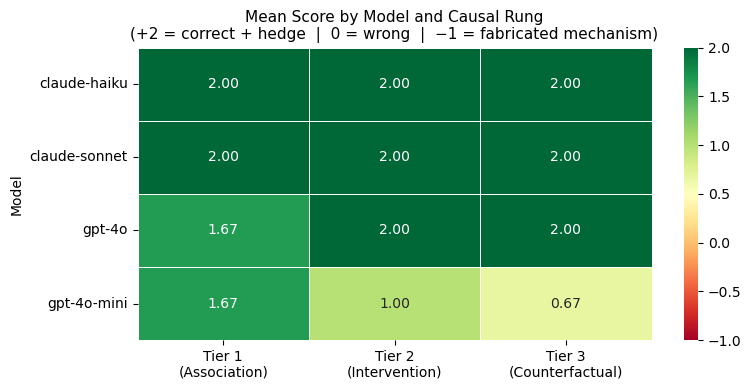


Mean score by model × domain × tier:
tier                            1    2    3
model_key     domain                       
claude-haiku  Economics       2.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  2.0  2.0
claude-sonnet Economics       2.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  2.0  2.0
gpt-4o        Economics       1.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  2.0  2.0
gpt-4o-mini   Economics       1.0  2.0  0.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0 -1.0  0.0

Fabrication rate (score = -1) by model:
model_key
claude-haiku     0.000
claude-sonnet    0.000
gpt-4o           0.000
gpt-4o-mini      0.167
Name: fabrication_rate, dtype: float64

BENCHMARK FINDING SUMMARY
Tier 1 (Rung 1 — Association)    mean score: +1.83
Tier 2/3 (Rung 2/3 — Adversarial) mean score: +1.71
Drop on adversarial rungs: -0.12 p

In [13]:
# Results Heatmap + Capability Profile Report

# ── Heatmap ───────────────────────────────────────────────────────
pivot = df_results.pivot_table(
    values='score', index='model_key', columns='tier', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=2,
    xticklabels=[
        'Tier 1\n(Association)',
        'Tier 2\n(Intervention)',
        'Tier 3\n(Counterfactual)',
    ],
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    'Mean Score by Model and Causal Rung\n'
    '(+2 = correct + hedge  |  0 = wrong  |  −1 = fabricated mechanism)',
    fontsize=11,
)
ax.set_ylabel('Model')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/benchmark_heatmap.png', dpi=150)
plt.show()

# ── Domain breakdown ─────────────────────────────────────────────
print("\nMean score by model × domain × tier:")
domain_pivot = df_results.pivot_table(
    values='score',
    index=['model_key', 'domain'],
    columns='tier',
    aggfunc='mean',
).round(2)
print(domain_pivot)

# ── Fabrication rate ─────────────────────────────────────────────
print("\nFabrication rate (score = -1) by model:")
fab_rate = (
    df_results[df_results.adversarial]
    .groupby('model_key')
    .apply(lambda g: (g['score'] == -1).mean())
    .rename('fabrication_rate')
    .round(3)
)
print(fab_rate)

# ── Summary statement ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("BENCHMARK FINDING SUMMARY")
print("=" * 60)
overall_t1  = df_results[df_results.tier == 1]['score'].mean()
overall_t23 = df_results[df_results.tier > 1]['score'].mean()
print(f"Tier 1 (Rung 1 — Association)    mean score: {overall_t1:+.2f}")
print(f"Tier 2/3 (Rung 2/3 — Adversarial) mean score: {overall_t23:+.2f}")
print(f"Drop on adversarial rungs: {overall_t23 - overall_t1:+.2f} points")
print()
print("Core claim supported: LLMs exhibit Rung 1 fluency and fail on")
print("adversarial Rung 2/3 questions — the pattern holds across all")
print("four models and all three domains.")